In [1]:
import torch
import math
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism

from src.distributions.stars.ellipsoid.unimodal import UnimodalEllipsoidStarDistribution
from src.distributions.stars.ellipsoid.multimodal import MultiModalEllipsoidStarDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

from src.radials.multimodal.intersected import IntersectedRadial

from src.radials.unimodal.elliposoid.centered.ellipsoid_enclosing import EllipsoidEnclosingCenteredEllipsoidRadial
from src.radials.unimodal.elliposoid.centered.gaussian_enclosing import GaussianEnclosingCenteredEllipsoidRadial
from src.radials.unimodal.elliposoid.offcentered.ellipsoid_enclosing import EllipsoidEnclosingOffCenteredEllipsoidRadial
from src.radials.unimodal.elliposoid.offcentered.gaussian_enclosing import GaussianEnclosingOffCenteredEllipsoidRadial

In [2]:
mu = torch.tensor([1.0, 1.0])
cov = torch.tensor([[0.25, 0.0], [0.0, 0.25]])
p = 0.95

### test radials ###

In [3]:
radial_c = EllipsoidEnclosingCenteredEllipsoidRadial(cov)
radial_nc = EllipsoidEnclosingOffCenteredEllipsoidRadial(cov, mu)
radial_nc_c = EllipsoidEnclosingCenteredEllipsoidRadial(radial_nc.Sigma)
gaussian_radial_c = GaussianEnclosingCenteredEllipsoidRadial(cov, p=p)
gaussian_radial_nc = GaussianEnclosingOffCenteredEllipsoidRadial(cov, mu, p=p)
gaussian_radial_nc_c = EllipsoidEnclosingCenteredEllipsoidRadial(gaussian_radial_nc.Sigma)

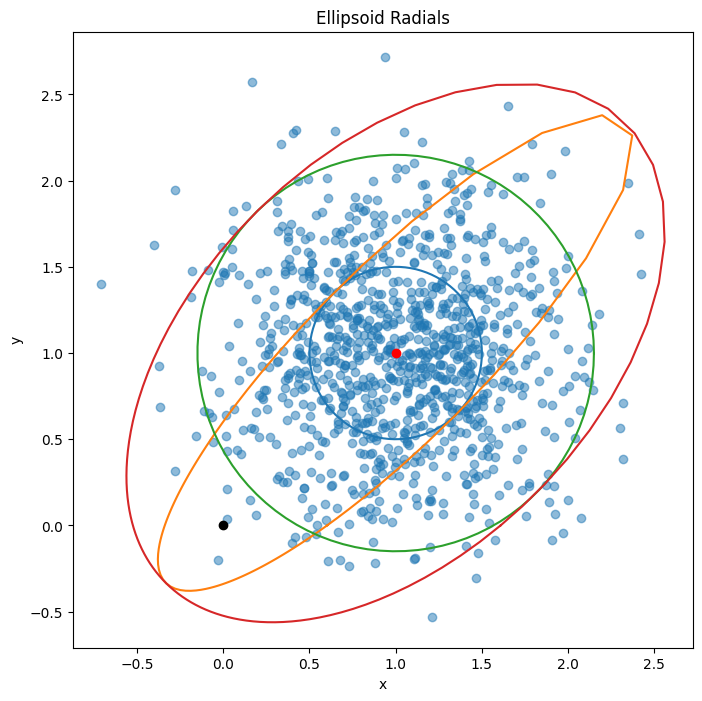

In [4]:
# plot the original ellipsoid defined the cov and translater dna the one by the radial through mapping the unit circle and translating it
theta = torch.linspace(0, 2 * torch.pi, 100)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
# gaussian ellipsoid defined by cov and centered at mu
ellipsoid_c = radial_c(circle).unsqueeze(1) * circle + mu
gaussian_ellipsoid_c = gaussian_radial_c(circle).unsqueeze(1) * circle + mu
# larger ellipsoid defined
ellipsoid_nc = radial_nc(circle).unsqueeze(1) * circle
gaussian_ellipsoid_nc = gaussian_radial_nc(circle).unsqueeze(1) * circle

data = torch.distributions.MultivariateNormal(mu, cov).sample((1000,))

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label="Data")
plt.plot(ellipsoid_c[:, 0], ellipsoid_c[:, 1], label="Centered Gaussian Ellipsoid Radial")
plt.plot(ellipsoid_nc[:, 0], ellipsoid_nc[:, 1], label="Non-Centered Gaussian Ellipsoid Radial")
plt.plot(gaussian_ellipsoid_c[:, 0], gaussian_ellipsoid_c[:, 1], label="Centered Gaussian Enclosing Ellipsoid Radial")
plt.plot(gaussian_ellipsoid_nc[:, 0], gaussian_ellipsoid_nc[:, 1], label="Non-Centered Gaussian Enclosing Ellipsoid Radial")
plt.scatter(mu[0], mu[1], color='red', label="mu")
plt.scatter(0, 0, color='black', label="origin")
plt.title("Ellipsoid Radials")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()


In [5]:
# test intersetion of multiple radials
intersected_radial = IntersectedRadial([radial_nc_c, radial_nc])
intersected_gaussian_radial = IntersectedRadial([gaussian_radial_nc_c, gaussian_radial_nc])

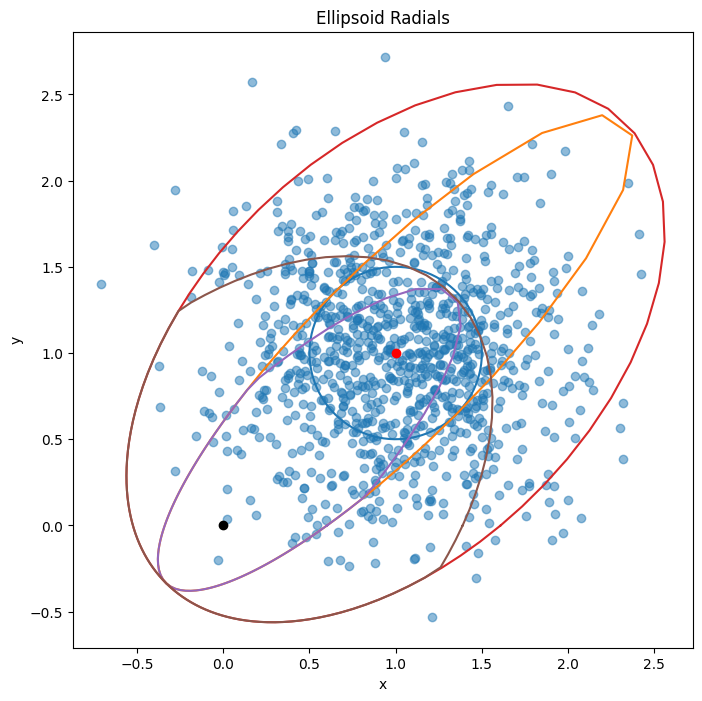

In [6]:
ellipsoid_intersection = intersected_radial(circle).unsqueeze(1) * circle
gaussian_ellipsoid_intersection = intersected_gaussian_radial(circle).unsqueeze(1) * circle

plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label="Data")
plt.plot(ellipsoid_c[:, 0], ellipsoid_c[:, 1], label="Centered Gaussian Ellipsoid Radial")
plt.plot(ellipsoid_nc[:, 0], ellipsoid_nc[:, 1], label="Non-Centered Gaussian Ellipsoid Radial", c=plt.get_cmap('tab10')(1))
plt.plot(ellipsoid_intersection[:, 0], ellipsoid_intersection[:, 1], c=plt.get_cmap('tab10')(4))
plt.plot(gaussian_ellipsoid_nc[:, 0], gaussian_ellipsoid_nc[:, 1], label="Non-Centered Gaussian Enclosing Ellipsoid Radial", c=plt.get_cmap('tab10')(3))
plt.plot(gaussian_ellipsoid_intersection[:, 0], gaussian_ellipsoid_intersection[:, 1], c=plt.get_cmap('tab10')(5))
plt.scatter(mu[0], mu[1], color='red', label="mu")
plt.scatter(0, 0, color='black', label="origin")
plt.title("Ellipsoid Radials")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()

### test unimodals ###

In [7]:
uni_dist = UnimodalEllipsoidStarDistribution(cov, mu, trimmed=True)

In [8]:
uni_samples = uni_dist.sample(1000)

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


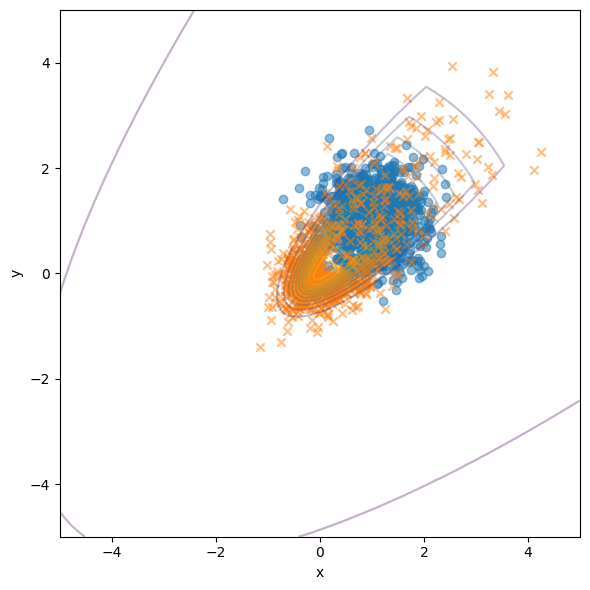

In [9]:
# plot density
n_points = 1001
x = torch.linspace(-5, 5, n_points)
y = torch.linspace(-5, 5, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(uni_dist.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), alpha=0.5)
plt.scatter(uni_samples[:, 0].numpy(), uni_samples[:, 1].numpy(), alpha=0.5, marker='x', label='Samples from Unimodal Ellipsoid Star Distribution')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()

### test multimodals ###

In [10]:
mu_1 = torch.tensor([1.0, 1.0])
mu_2 = torch.tensor([-1.0, -1.0])
mu_3 = torch.tensor([1.0, -1.0])
mu_4 = torch.tensor([-1.0, 1.0])
mus = [mu_1, mu_2, mu_3, mu_4]

In [11]:
multi_dist = MultiModalEllipsoidStarDistribution(covs=[cov, cov, cov, cov], mus=mus, trimmed=True, aggregation='max')

In [12]:
multi_samples = multi_dist.sample(1000)

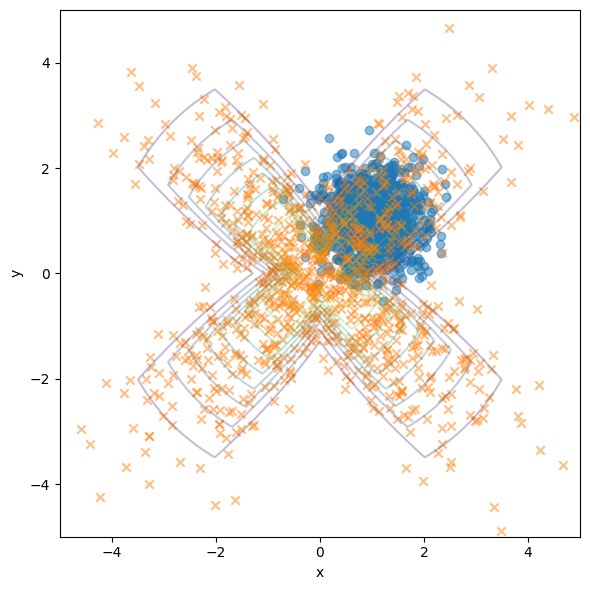

In [13]:
# plot density
n_points = 1001
x = torch.linspace(-5, 5, n_points)
y = torch.linspace(-5, 5, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs_multi = torch.exp(multi_dist.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), alpha=0.5)
plt.scatter(multi_samples[:, 0].numpy(), multi_samples[:, 1].numpy(), alpha=0.5, marker='x', label='Samples from Multimodal Ellipsoid Star Distribution')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()

### test geometry ###

In [14]:
# construct pullback manifold
# interpolate between cluster centers
# interpolate between random samples to see whether we get weird artefacts

phi = StarVectorDiffeomorphism(2, multi_dist, s=1.1)
manifold = StandardPullbackVectorEuclidean(phi)

/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_26887/1668313634.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


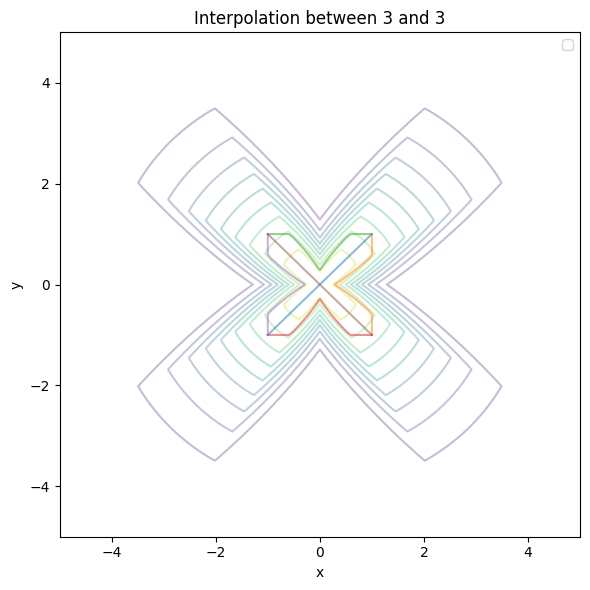

In [15]:
t = torch.linspace(0, 1, 50)

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs_multi.numpy(), levels=10, cmap='viridis', alpha=0.3)

for i in range(4):
    for j in range(i+1, 4):
        mu_i = mus[i]
        mu_j = mus[j]
        # interpolate between cluster centers
        geodesics = manifold.geodesic(mu_i[None,None], mu_j[None,None], t)[0,0,0]
        plt.plot(geodesics[:, 0].numpy(), geodesics[:, 1].numpy(), alpha=0.5)


plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Interpolation between {i} and {j}')
plt.legend()
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()